# Лабораторная работа 4: Кластеризация

## Часть 1 - Работа со сгенерированными данными

**Импорт библиотек и создание функции генерации датасета**

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples

plt.rcParams['figure.figsize'] = (9, 6)

def make_data(n, seed):
    np.random.seed(seed)
    shift_matrix = np.array([[3, 3], [6, 9], [9, 3]])
    data = np.random.randn(3, 2, n) + shift_matrix.reshape((3, 2, 1))
    data = np.swapaxes(data, 1, 2).reshape((-1, 2))
    data *= np.array([[20, 0.5]])
    df = pd.DataFrame({'x': data[:, 0], 'y': data[:, 1]})
    return df.sample(frac=1.0).reset_index(drop=True)

df1 = make_data(60, seed=42)
df1.head()

,x,y
0,165.846611,1.344867
1,88.986731,4.276743
2,91.962979,4.741236
3,175.837555,1.655454
4,100.189273,4.736619


**Стандартизация данных**

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df1[['x','y']])
print("Первые 5 стандартизированных наблюдений:")
X_scaled[:5]

Первые 5 стандартизированных наблюдений:


array([[ 0.86216204, -0.78276186],
       [-0.56641558,  1.17829743],
       [-0.51109672,  1.48898577],
       [ 1.04786152, -0.57501779],
       [-0.3581964 ,  1.48589731]])

**KMeans для трех кластеров (k=3)**

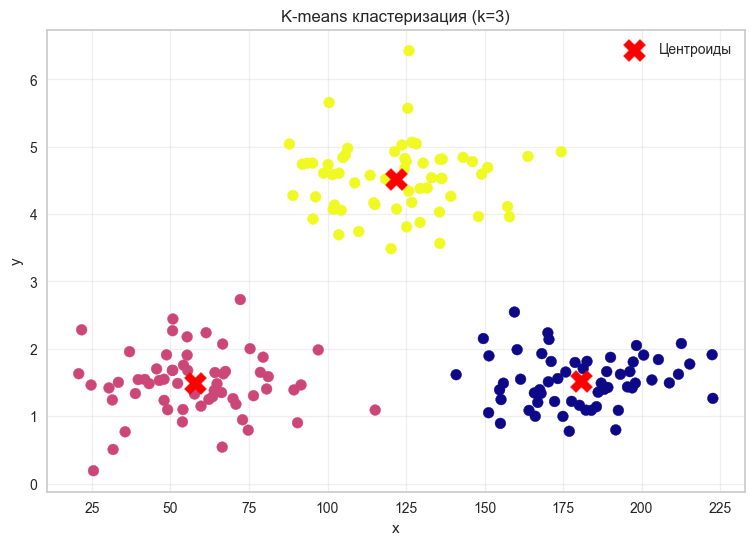

Коэффициент силуэта для 3 кластеров: 0.7240


In [24]:
# Кластеризация для k=3
kmeans3 = KMeans(n_clusters=3, random_state=123)
labels3 = kmeans3.fit_predict(X_scaled)

# Добавление меток кластеров в данные
df1['cluster3'] = labels3

# Визуализация
plt.scatter(df1['x'], df1['y'], c=labels3, cmap='plasma', s=60)
centers = scaler.inverse_transform(kmeans3.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1], s=250, c='red', marker='X', label='Центроиды')
plt.title('K-means кластеризация (k=3)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Вычисление и вывод коэффициента силуэта
sil3 = silhouette_score(X_scaled, labels3)
print(f'Коэффициент силуэта для 3 кластеров: {sil3:.4f}')

Вывод:
На графике чётко видны три обособленные группы, что подтверждает эффективность работы алгоритма на данном наборе данных.
Для количественной оценки качества кластеризации был вычислен коэффициент силуэта (silhouette score). Полученное значение 0.7240 находится близко к 1, что указывает на хорошую плотность объектов внутри кластеров, достаточную разделённость между различными кластерами, высокое качество выполненной кластеризации.

**Повтор алгоритма KMeans для k = 2 и k = 4**

In [25]:
# Сравнительный анализ для k=2,3,4
results = {}
for k in [2, 3, 4]:
    model = KMeans(n_clusters=k, random_state=123)
    labels = model.fit_predict(X_scaled)
    results[k] = silhouette_score(X_scaled, labels)

print("Результаты сравнения кластеризации:")
print(f"k=2: {results[2]:.4f}")
print(f"k=3: {results[3]:.4f}")
print(f"k=4: {results[4]:.4f}")

Результаты сравнения кластеризации:
k=2: 0.4945
k=3: 0.7240
k=4: 0.5700


Выводы:
* Наилучшее качество достигается при k=3 (silhouette = 0.7240), что подтверждает исходное предположение о наличии трёх естественных групп в данных.
* Худшее качество наблюдается при k=2 (silhouette = 0.4945), что объясняется объединением двух из трёх исходных кластеров в одну группу, что нарушает естественную структуру данных.
* Увеличение числа кластеров до 4 (k=4) приводит к снижению качества (silhouette = 0.5700) по сравнению с k=3, что указывает на избыточное дробление данных.

Оптимальным количеством кластеров для данного набора данных является k=3, так как это значение максимизирует коэффициент силуэта и соответствует исходной генеративной структуре данных.

**Метод локтя**

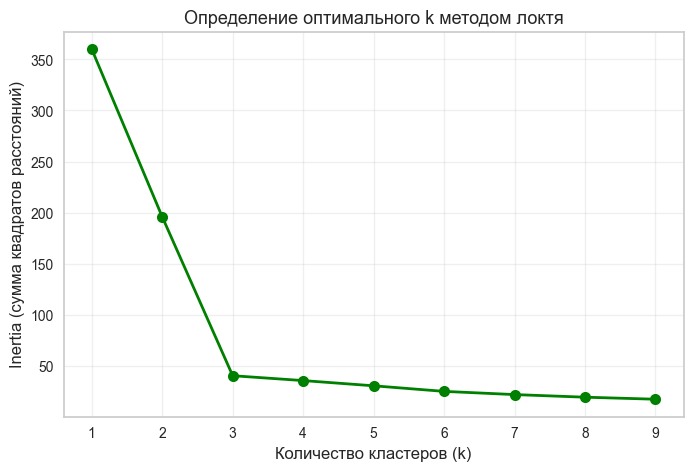

In [26]:
# Вычисляем инерцию для k от 1 до 9
inertia_values = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=123).fit(X_scaled)
    inertia_values.append(km.inertia_)

# Визуализация метода
plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertia_values, marker='o', linewidth=2, markersize=8, color='green')
plt.xlabel('Количество кластеров (k)', fontsize=12)
plt.ylabel('Inertia (сумма квадратов расстояний)', fontsize=12)
plt.title('Определение оптимального k методом локтя', fontsize=13)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 10))

plt.show()

Вывод: На полученном графике (рисунок 5) наблюдается выраженный изгиб («локоть») в районе k = 3. После трёх кластеров кривая инерции выходит на практически линейный участок, что свидетельствует о том, что дальнейшее увеличение числа групп не приводит к существенному улучшению компактности кластеров.

Таким образом, метод локтя подтверждает выводы, сделанные на основе анализа коэффициента силуэта: трёх кластеров достаточно для адекватного описания структуры данных, а добавление четвёртой группы приводит лишь к избыточному дроблению без качественного улучшения кластеризации.

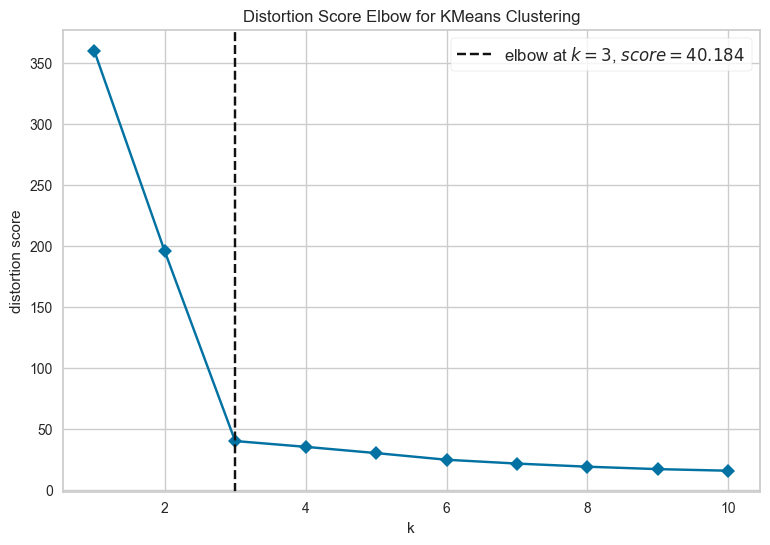

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [27]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=123)

visualizer = KElbowVisualizer(model, k=(1, 11), timings=False)
visualizer.fit(X_scaled)
visualizer.show()

Выводы: построенный график показывает выраженный "излом" в области k = 3. После трёх кластеров уменьшение значения критерия происходит значительно медленнее, что подтверждает наличие характерной структуры именно с тремя естественными группами.

## Выводы к Части 1

1. Оптимальное количество кластеров для данного набора данных равно трём, что полностью соответствует исходной генеративной модели данных (функция make_data создаёт именно три группы).
2. Алгоритм K-means успешно справляется с задачей кластеризации при правильном выборе параметра k, демонстрируя высокое качество разбиения (коэффициент силуэта близок к 1).
3. Метод локтя является эффективным инструментом для определения оптимального числа кластеров, особенно когда истинная структура данных неизвестна.
4. Сравнительный анализ метрик качества (коэффициент силуэта для разного k) подтвердил, что как уменьшение, так и увеличение числа кластеров относительно оптимального значения приводит к ухудшению качества кластеризации.

Данное исследование подтвердило теоретические положения о работе алгоритма K-means и продемонстрировало практические аспекты выбора оптимального количества кластеров в задачах кластеризации.

## Часть 2 — Работа с набором данных bank_loan_default.csv

In [28]:
df = pd.read_csv('bank_loan_default.csv')
df.head()

,age,annual_income,employment_type,education,loan_amount,interest_rate_pct,term_months,credit_score,num_open_accounts,delinquency_30d,residence_type,Default
0,42,57272.0,Self-Employed,Masters,8516.0,5.85,48,730.0,10,No,Own,0
1,51,45786.0,Salaried,Masters,13760.0,9.97,36,677.0,7,No,Mortgage,0
2,69,42359.0,Salaried,Bachelors,2569.0,13.75,48,624.0,2,No,Own,0
3,65,50709.0,Self-Employed,Masters,13204.0,8.70,48,698.0,3,No,Rent,0
4,30,46272.0,Salaried,HS,7700.0,7.53,48,532.0,7,No,Rent,0


**Предобработка данных**

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3041 entries, 0 to 3040
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                3041 non-null   int64  
 1   annual_income      3041 non-null   float64
 2   employment_type    3041 non-null   object 
 3   education          3041 non-null   object 
 4   loan_amount        3041 non-null   float64
 5   interest_rate_pct  3041 non-null   float64
 6   term_months        3041 non-null   int64  
 7   credit_score       3041 non-null   float64
 8   num_open_accounts  3041 non-null   int64  
 9   delinquency_30d    3041 non-null   object 
 10  residence_type     3041 non-null   object 
 11  Default            3041 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 285.2+ KB


Данные о кредитах:

* age — возраст заёмщика (лет), числовой.
* annual_income — годовой доход, USD/год, числовой (широкий диапазон).
* employment_type — тип занятости: Salaried / Self-Employed / Unemployed,категориальный.
* education — образование: HS / Bachelors / Masters / PhD, категориальный.
* loan_amount — сумма кредита, USD, числовой (широкий диапазон).
* interest_rate_pct — процентная ставка по кредиту, % годовых, числовой.
* term_months — срок кредита, месяцев (набор фиксированных значений: 24/36/48/60/72), числовой/категориальный.
* credit_score — кредитный скор (от 300 до 850), числовой.
* um_open_accounts — число открытых кредитных счетов, целочисленныйь счётчик.
* delinquency_30d — просрочка платежа 30 дней: Yes / No, категориальный.
* residence_type — жильё: Own / Rent / Mortgage, категориальный.
* Default — целевой класс: 1 — дефолт по кредиту, 0 — нет.

In [30]:
df['term_months'] = df['term_months'].astype('object')
cat_cols = ['employment_type', 'education', 'term_months', 'delinquency_30d', 'residence_type']
num_cols = [c for c in df.columns if c not in cat_cols + ['Default']]

num_cols

['age',
 'annual_income',
 'loan_amount',
 'interest_rate_pct',
 'credit_score',
 'num_open_accounts']

**Матрица диаграмм рассеяния**

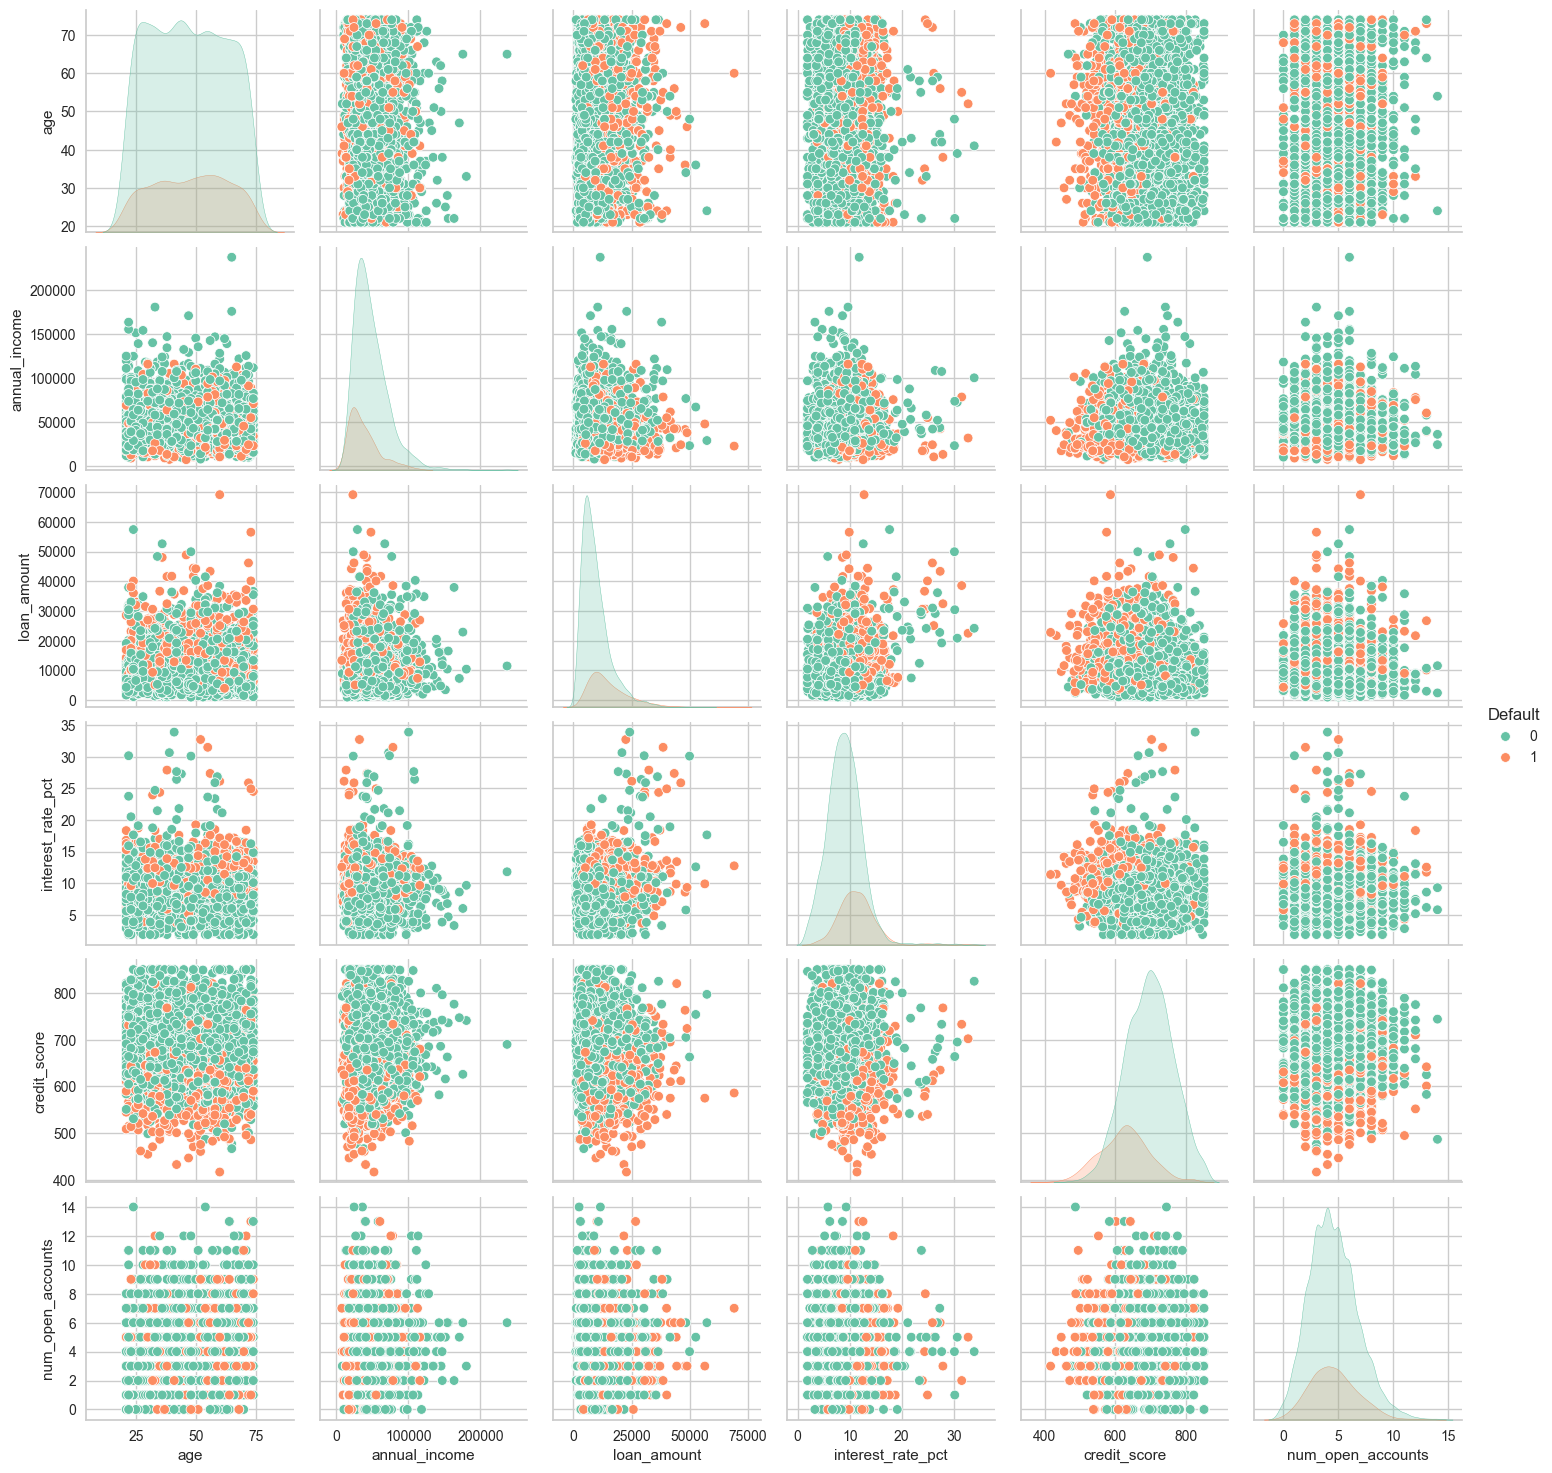

In [31]:
import seaborn as sns
sns.pairplot(df[num_cols + ['Default']], hue='Default', diag_kind='kde' , palette='Set2')
plt.show()

**Стандартизация числовых данных**

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])
X_scaled[:5]

array([[-3.26255352e-01,  4.89032122e-01, -2.93528077e-01,
        -1.01799205e+00,  6.67669832e-01,  2.50694585e+00],
       [ 2.50758071e-01,  1.68941365e-03,  4.16689533e-01,
         1.51503308e-01, -5.84066945e-02,  1.12801983e+00],
       [ 1.40478492e+00, -1.43715728e-01, -1.09895602e+00,
         1.22448691e+00, -7.84483221e-01, -1.17019021e+00],
       [ 1.14833451e+00,  2.10568758e-01,  3.41388047e-01,
        -2.08996474e-01,  2.29284005e-01, -7.10548201e-01],
       [-1.09560658e+00,  2.23100436e-02, -4.04042488e-01,
        -5.41110447e-01, -2.04484247e+00,  1.12801983e+00]])

**Подбор оптимального k**

In [33]:
scores = {}
for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=0).fit(X_scaled)
    labels = km.labels_
    sil = silhouette_score(X_scaled, labels)
    scores[k] = sil

scores

{2: np.float64(0.13591705616382413),
 3: np.float64(0.1416851381552817),
 4: np.float64(0.14076590569691128),
 5: np.float64(0.1292633166431947),
 6: np.float64(0.13344225632159598),
 7: np.float64(0.1265283128990342),
 8: np.float64(0.12093398361559632),
 9: np.float64(0.12267237883689691),
 10: np.float64(0.11974090506854955)}

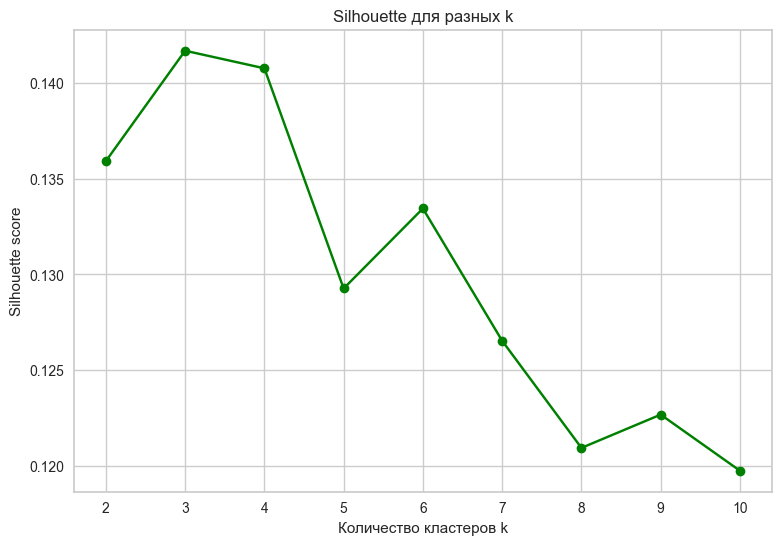

In [34]:
plt.plot(list(scores.keys()), list(scores.values()), marker='o' , color = 'green')
plt.xlabel('Количество кластеров k')
plt.ylabel('Silhouette score')
plt.title('Silhouette для разных k')
plt.show()

**Итоговая модель KMeans**

In [35]:
best_k = max(scores, key=scores.get)
best_k

3

In [36]:
kmeans_final = KMeans(n_clusters=best_k, random_state=0)
labels_final = kmeans_final.fit_predict(X_scaled)

df['cluster'] = labels_final
df.groupby('cluster')[num_cols].mean()


,age,annual_income,loan_amount,interest_rate_pct,credit_score,num_open_accounts
cluster,,,,,,
0,61.350746,46369.295191,8438.063847,8.797894,688.159204,4.764511
1,33.573808,46621.180924,8265.706132,9.100104,694.610901,4.495079
2,48.359922,42035.392996,22164.670817,11.798058,630.780156,4.163424


На основе средних значений числовых признаков можно выделить три характерные группы заёмщиков:
Кластер 0: «Зрелые консервативные заёмщики»:
- Самый высокий средний возраст (61.35 лет)
- Средний доход (46,369 USD/год)
- Небольшие суммы кредитов (8,438 USD)
- Низкая процентная ставка (8.80%)
- Высокий кредитный рейтинг (688.16)
- Наибольшее количество открытых счетов (4.76)
Итого: Пожилые клиенты с хорошей кредитной историей, берущие небольшие кредиты на выгодных условиях.

Кластер 1: «Молодые стандартные заёмщики»:
- Самый молодой средний возраст (33.57 лет)
- Наивысший доход (46,621 USD/год)
- Малые суммы кредитов (8,266 USD)
- Умеренная процентная ставка (9.10%)
- Лучший кредитный рейтинг (694.61)
- Меньше открытых счетов (4.50)
Итого: Молодые клиенты с высоким доходом и отличной кредитной историей, получающие небольшие кредиты.

Кластер 2: «Заёмщики повышенного риска»:
- Средний возраст (48.36 лет)
- Самый низкий доход (42,035 USD/год)
- Крупнейшие суммы кредитов (22,165 USD)
- Наивысшая процентная ставка (11.80%)
- Низкий кредитный рейтинг (630.78)
- Наименьшее количество счетов (4.16)
Итого: Клиенты среднего возраста с относительно низким доходом, берущие крупные кредиты по высоким ставкам, что указывает на повышенный риск дефолта.


**Метрики качества кластеризации**

In [37]:
from sklearn import metrics

metrics_results = {
    'silhouette': silhouette_score(X_scaled, labels_final),
    'ARI': metrics.adjusted_rand_score(df['Default'], labels_final),
    'AMI': metrics.adjusted_mutual_info_score(df['Default'], labels_final),
    'FMI': metrics.fowlkes_mallows_score(df['Default'], labels_final),
    'V-measure': metrics.v_measure_score(df['Default'], labels_final)
}

metrics_results

{'silhouette': np.float64(0.1416851381552817),
 'ARI': 0.1120770613374959,
 'AMI': np.float64(0.09474462989283808),
 'FMI': np.float64(0.5634105212672075),
 'V-measure': np.float64(0.09513297787183422)}

Вывод : Кластеризация методом K-means успешно выделила три группы клиентов, различающихся по таким характеристикам, как возраст, доход, сумма кредита и кредитный рейтинг. Однако анализ внешних метрик качества (ARI, AMI, V-measure) показал слабую корреляцию этих кластеров с фактическим наличием дефолта.
Низкие значения внешних метрик указывают на то, что:
Структура данных, выявленная алгоритмом K-means, не совпадает напрямую с бинарным разделением на дефолтных и недефолтных клиентов.
Кластеры формируются на основе комплексных многомерных зависимостей, а не отдельных признаков, напрямую связанных с дефолтом.
Для задачи прогнозирования дефолта целесообразнее применять методы классификации с учителем, а не кластеризацию.
В то же время, сам факт выделения кластеров (подтверждаемый коэффициентом силуэта) свидетельствует о наличии внутренней структуры в данных о кредитных операциях, что может быть полезно для задач сегментации клиентов и риск-менеджмента, отличных от прямого предсказания дефолта.

**Агломеративная кластеризация**

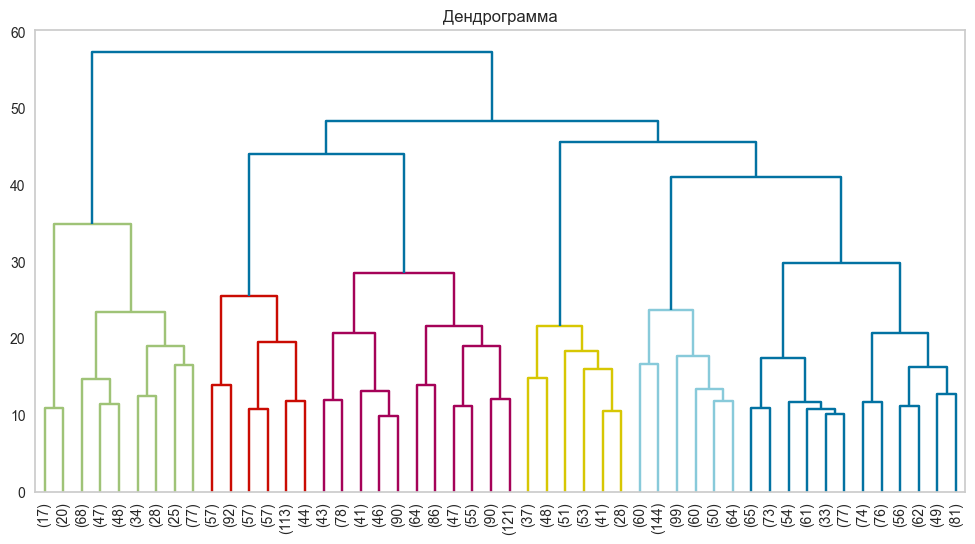

In [38]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked,
           truncate_mode='lastp',
           p=50,
           show_leaf_counts=True,  
           leaf_rotation=90,       
           leaf_font_size=10,       
           )   
plt.title('Дендрограмма')
plt.grid(False)
plt.show()

**Кластеризация по агломеративному методу**

In [39]:
optimal_k = 3

In [40]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=optimal_k)
labels_agg = agg.fit_predict(X_scaled)

df['cluster_agg'] = labels_agg


In [41]:
df.groupby('cluster_agg')[num_cols].mean()

,age,annual_income,loan_amount,interest_rate_pct,credit_score,num_open_accounts
cluster_agg,,,,,,
0,54.671123,49256.209893,8782.432219,9.053505,704.802807,4.302807
1,45.747253,43285.708791,24955.634615,10.902901,665.041209,4.563187
2,37.897544,42058.301439,8692.272650,9.469094,656.445385,4.848434


In [42]:
from sklearn import metrics

metrics_agg = {
    'silhouette': metrics.silhouette_score(X_scaled, labels_agg),
    'ARI': metrics.adjusted_rand_score(df['Default'], labels_agg),
    'AMI': metrics.adjusted_mutual_info_score(df['Default'], labels_agg),
    'FMI': metrics.fowlkes_mallows_score(df['Default'], labels_agg),
    'V-measure': metrics.v_measure_score(df['Default'], labels_agg)
}

metrics_agg


{'silhouette': np.float64(0.08149433116662708),
 'ARI': 0.07502686447732167,
 'AMI': np.float64(0.04275031212308778),
 'FMI': np.float64(0.5623361807835635),
 'V-measure': np.float64(0.04317753482306022)}

**Метрики при разном количестве кластеров:**

метрики 3 кластеров
- 'silhouette': 0.08149433116662708,
- 'ARI': 0.07502686447732167,
- 'AMI': 0.042750312123087775,
- 'FMI': 0.5623361807835635,
- 'V-measure': 0.04317753482306022

метрики  5 кластеров
- 'silhouette': 0.07521954475574781,
- 'ARI': 0.046866373496295376,
- 'AMI': 0.03376842870668728,
- 'FMI': 0.457940699554776,
- 'V-measure': 0.03442002469010543

метрики  6 кластеров
 - 'silhouette': 0.0689584691479699,
 - 'ARI': 0.025912746197384977,
 - 'AMI': 0.04026836435523272,
 - 'FMI': 0.3803684782935322,
 - 'V-measure': 0.04097875915871389

Увеличение числа кластеров до 5 или 6 снижает силуэт и FMI, что подтверждает, что оптимальным числом для агломеративной кластеризации также является 3 кластера.
Агломеративная кластеризация показала худшие результаты, чем K-means, по большинству метрик качества.
Оптимальное число кластеров = 3 для обоих методов, но агломеративный даёт менее компактные и хуже разделённые группы.
Низкие значения внешних метрик (ARI, AMI, V-measure < 0.1) подтверждают, что ни один метод не выявляет структуру, сильно коррелирующую с дефолтом.
FMI остаётся относительно высоким (~0.56) для k=3 в обоих методах, что может указывать на частичное совпадение кластерной структуры с истинным разделением, но недостаточное для практического применения.

## Вывод ко 2 части

Кластеризация данных о кредитах позволила выявить три характерные группы клиентов с помощью обоих методов — K-means и агломеративной кластеризации.
Для данных о кредитах K-means предпочтительнее, так как он создаёт более чёткие и интерпретируемые кластеры с лучшими метриками качества.
Оба метода кластеризации — K-means и агломеративный — показали схожую способность разделять клиентов на три группы.
K-means продемонстрировал более высокое качество кластеризации (коэффициент силуэта 0.142 против 0.081), формируя более компактные и чётко разделённые кластеры.
Агломеративный метод оказался полезен для визуального анализа структуры данных через дендрограмму и выявления специфических подгрупп, таких как клиенты с экстремально высокими суммами кредитов.
Однако ни один из методов не показал сильной корреляции с целевой переменной Default (внешние метрики < 0.12). Это указывает на то, что для прогнозирования дефолта следует применять методы классификации с учителем, а кластеризацию использовать преимущественно для задач сегментации и анализа структуры клиентской базы.

## Выводы к лабораторной работе

В ходе выполнения лабораторной работы были изучены и применены два основных метода кластеризации: алгоритм K-means и иерархическая агломеративная кластеризация. Работа включала анализ как синтетических данных с известной структурой, так и реальных данных о кредитных операциях.

На синтетических данных оба метода успешно выявили три исходные группы, что подтверждается высоким коэффициентом силуэта и визуальной отчётливостью кластеров. Метод локтя и автоматизированные инструменты Yellowbrick согласованно указали на оптимальное значение k = 3.

На реальных кредитных данных кластеризация позволила выделить три характерные группы клиентов, различающиеся по возрасту, доходу, размеру кредита и кредитному рейтингу. Однако связь этих кластеров с фактом дефолта оказалась слабой, о чём свидетельствуют низкие значения внешних метрик (ARI, AMI, V-measure < 0.12).

K-means продемонстрировал более высокое качество кластеризации (silhouette = 0.142) по сравнению с агломеративным методом (silhouette = 0.081), формируя более компактные и устойчивые группы. Агломеративная кластеризация оказалась ценна для визуального анализа структуры данных и выявления специфических подгрупп, таких как клиенты с экстремально высокими суммами кредитов.

Таким образом, для сегментации клиентов по демографическим и финансовым признакам предпочтительнее использовать K-means, в то время как для прогнозирования дефолта необходимо применять методы классификации с учителем.

Работа позволила на практике сравнить различные подходы к кластеризации, оценить их сильные и слабые стороны, а также определить область их эффективного применения для решения реальных аналитических задач.



# Доп.задания

## Задание 6

Задача: Выполнить подсчёт 4 любых метрик для разного количества кластеров (от 2 до 10). Построить график - по оси х - кол-во кластеров, по у - значение метрики (отразить все 4 метрики на одном графике разным цветом).

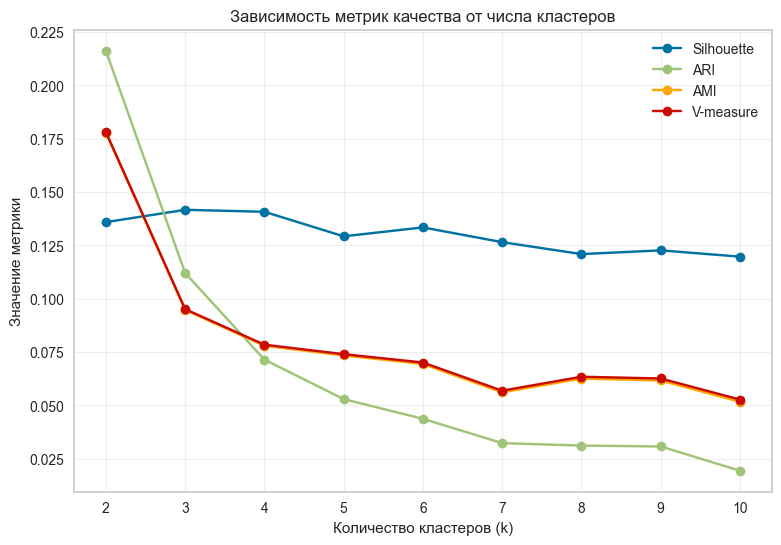

In [44]:
k_range = range(2, 11)

silhouette_scores = []
ari_scores = []
ami_scores = []
vmeasure_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(X_scaled)
    
    silhouette_scores.append(metrics.silhouette_score(X_scaled, labels))
    ari_scores.append(metrics.adjusted_rand_score(df['Default'], labels))
    ami_scores.append(metrics.adjusted_mutual_info_score(df['Default'], labels))
    vmeasure_scores.append(metrics.v_measure_score(df['Default'], labels))

# Визуализация
plt.figure(figsize=(9, 6))

plt.plot(k_range, silhouette_scores, marker='o', label='Silhouette')
plt.plot(k_range, ari_scores, marker='o', label='ARI')
plt.plot(k_range, ami_scores, marker='o', label='AMI', color = 'orange')
plt.plot(k_range, vmeasure_scores, marker='o', label='V-measure')

plt.xlabel('Количество кластеров (k)')
plt.ylabel('Значение метрики')
plt.title('Зависимость метрик качества от числа кластеров')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

**Вывод к графику:**

На графике представлена зависимость четырёх метрик качества кластеризации от количества кластеров (k) в диапазоне от 2 до 10. Метрики включают коэффициент силуэта (Silhouette, синяя линия), ARI-метрику (ARI, зелёная линия), AMI-метрику (AMI, оранжевая линия) и V-меру (V-measure, красная линия). Все метрики демонстрируют общую тенденцию к снижению по мере увеличения k, что указывает на ухудшение качества кластеризации при большем числе кластеров.

Коэффициент силуэта, как внутренняя метрика, оценивающая компактность и разделимость кластеров без использования истинных меток, достигает максимального значения около 0.150 при k=2–3, после чего плавно снижается до значений близких к 0.125 и ниже. Это свидетельствует о том, что при небольшом количестве кластеров (2–3) кластеры относительно плотные и хорошо разделены, но дальнейшее увеличение k приводит к переразбиению данных, где объекты внутри кластеров становятся менее связанными, а межкластерные расстояния уменьшаются, снижая общую эффективность.

Внешние метрики (ARI, AMI и V-measure), которые сравнивают полученные кластеры с истинными метками классов, также показывают пик при k=2: ARI ≈0.22, AMI ≈0.175, V-measure ≈0.175. Эти значения уменьшаются по мере роста k, приближаясь к нулю при k=10. Высокие начальные значения ARI указывают на умеренную согласованность кластеризации с бинарной классификацией дефолта при минимальном k, где кластеры могут приблизительно соответствовать группам "дефолт/не дефолт". Однако низкие абсолютные значения всех внешнихх метрик (менее 0.25) подчёркивают слабую корреляцию между кластерами и истинными классами, что предполагает, что структура данных не сильно ориентирована на разделение по дефолту, и кластеризация лучше подходит для сегментации, а не для прямого предсказания.

Наблюдается практически полное совпадение линий AMI (оранжевая) и V-measure (красная) на всём диапазоне k от 2 до 10. Обе метрики основаны на взаимной информации и в случае бинарной целевой переменной (как Default = 0/1) принимают идентичные значения. AMI — измеряет согласованность двух значений, V-measure — гармоническое среднее однородности и полноты, которые эквивалентны в двухклассовой задаче. Это подтверждает корректность расчётов, но не добавляет новой информации; различия могут проявиться только в многоклассовых сценариях. В текущей задаче совпадение подчёркивает ограниченность кластеризации для бинарного разделения.

В целом, график подтверждает оптимальность k=2–3 для данного датасета, как по внутренним, так и по внешним критериям, что согласуется с результатами метода локтя и анализа силуэта в основной части работы. Низкие значения метрик указывают на отсутствие ярко выраженной кластерной структуры в реальных данных о кредитах, возможно, из-за высокой размерности или шума в признаках.

## Задание 7

Задача: Выполнить нормализацию данных с помощью MinMaxScaler, MaxAbsScaler и сравнить полученные итоговые метрики с теми, что были получены на данных, нормализованных с помощью StandardScaler.

In [46]:
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler

scalers = {
    'StandardScaler': X_scaled,  # уже посчитан ранее
    'MinMaxScaler': MinMaxScaler().fit_transform(df[num_cols]),
    'MaxAbsScaler': MaxAbsScaler().fit_transform(df[num_cols])
}

scaling_results = {}

for scaler_name, X in scalers.items():
    km = KMeans(n_clusters=best_k, random_state=0)
    labels = km.fit_predict(X)
    
    scaling_results[scaler_name] = {
        'silhouette': metrics.silhouette_score(X, labels),
        'ARI': metrics.adjusted_rand_score(df['Default'], labels),
        'AMI': metrics.adjusted_mutual_info_score(df['Default'], labels),
        'V-measure': metrics.v_measure_score(df['Default'], labels)
    }

pd.DataFrame(scaling_results).T

,silhouette,ARI,AMI,V-measure
StandardScaler,0.141685,0.112077,0.094745,0.095133
MinMaxScaler,0.193919,0.001073,0.002689,0.003098
MaxAbsScaler,0.220692,0.001197,-0.000304,0.000116


**Вывод к полученным данным:**

В рамках дополнительного исследования было проведено сравнение результатов кластеризации методом k-means при использовании различных способов нормализации данных: StandardScaler, MinMaxScaler и MaxAbsScaler. Для всех вариантов использовалось одинаковое число кластеров, определённое ранее как оптимальное, а качество кластеризации оценивалось с помощью метрик Silhouette, ARI, AMI и V-measure.

Анализ результатов показал, что при использовании StandardScaler значения внешних метрик качества (ARI, AMI, V-measure) оказываются существенно выше по сравнению с другими методами масштабирования. Это свидетельствует о том, что кластеры, полученные после стандартизации, в большей степени согласуются с целевой переменной Default. Несмотря на относительно невысокое значение коэффициента силуэта, данный вариант обеспечивает наилучший баланс между внутренним качеством кластеров и их интерпретируемостью с точки зрения исходной задачи.

В случае применения MinMaxScaler и MaxAbsScaler наблюдаются более высокие значения коэффициента силуэта, что указывает на формирование более компактных и геометрически разделимых кластеров. Однако при этом значения внешних метрик (ARI, AMI, V-measure) стремятся к нулю, а в отдельных случаях принимают отрицательные значения. Это означает, что полученные кластеры практически не согласуются с фактическим распределением целевой переменной и не отражают структуру данных, связанную с кредитным дефолтом.

Полученные результаты объясняются особенностями алгоритма k-means, который основан на евклидовых расстояниях и чувствителен к масштабам признаков. StandardScaler, приводящий признаки к нулевому среднему и единичной дисперсии, обеспечивает более корректное соотношение вкладов признаков в расстояния между объектами. В то же время методы MinMaxScaler и MaxAbsScaler усиливают влияние выбросов и не учитывают различия в дисперсиях признаков, что приводит к формированию кластеров, слабо связанных с целевой переменной.

Таким образом, несмотря на более высокие значения коэффициента силуэта при использовании MinMaxScaler и MaxAbsScaler, наиболее целесообразным методом нормализации для данной задачи является StandardScaler, поскольку он обеспечивает наилучшее согласие результатов кластеризации с целевой переменной и является предпочтительным при использовании алгоритма k-means в задачах анализа кредитных данных.